# 04 Feature Baseline EDA

Part A extracts (or loads cached) handcrafted acoustic/prosodic features; Part B does leakage-aware separability analysis at the **subject level**, since a subject's ~29 recordings are correlated and file-level analysis would overstate separability. Background is in [`DATA_CONTEXT.md`](DATA_CONTEXT.md).

Primary questions:
- Which features separate MDD from HC at the subject level (not file level)?
- How does that compare against the metadata-side separation found in `02_clinical_metadata_eda.ipynb` (GAD-7, PSQI)?
- How redundant are the extracted features?

Inputs: `backend/data/processed/subjects_labeled.csv` (01), `backend/data/processed/audio_qa_manifest.csv` (03).
Output: `backend/data/processed/features.csv` (cached; Part A only re-extracts if this is missing).

**Runtime note:** Part A extracts ~70 features per file for every valid, non-outlier recording (~1490 files) via `librosa` — expect this to take several minutes the first time. Subsequent runs load the cached CSV and skip straight to Part B.

In [1]:
import sys
from pathlib import Path

_nb_dir = Path("backend/notebooks") if Path("backend/notebooks").exists() else Path.cwd()
if str(_nb_dir) not in sys.path:
    sys.path.insert(0, str(_nb_dir))

import numpy as np
import pandas as pd
from _eda_utils import bootstrap_project_paths, load_processed, mannwhitney_effect_size, elapsed_timer

PROJECT_ROOT = bootstrap_project_paths()

from mendxai.core.config import config
from mendxai.ml.feature_extractor import FeatureExtractor

qa_df = load_processed("audio_qa_manifest.csv")

excluded = qa_df[qa_df["duration_outlier"]]
included_df = qa_df[~qa_df["duration_outlier"]].reset_index(drop=True)
print(f"QA manifest: {len(qa_df)} valid files, excluding {len(excluded)} duration outliers -> {len(included_df)} files for feature extraction")
print("(the 5 unreadable files from subject 02010004 are already absent from audio_qa_manifest.csv — see DATA_CONTEXT.md section 9)")

Loaded 1503 rows from /Users/vishalkarda/Documents/Projects/mendx.ai/backend/data/processed/audio_qa_manifest.csv
QA manifest: 1503 valid files, excluding 12 duration outliers -> 1491 files for feature extraction
(the 5 unreadable files from subject 02010004 are already absent from audio_qa_manifest.csv — see DATA_CONTEXT.md section 9)


In [2]:
FEATURES_PATH = config.data.processed_data_dir / "features.csv"
extractor = FeatureExtractor()

if FEATURES_PATH.exists():
    features_df = extractor.load_features()
else:
    audio_paths = [Path(p) for p in included_df["path"]]
    labels = included_df["label"].tolist()
    with elapsed_timer("feature extraction"):
        features_df = extractor.extract_features_batch(audio_paths, labels)
    config.ensure_output_dirs()
    extractor.save_features(features_df)

display(features_df.head())
print(f"\nShape: {features_df.shape}")

Loaded features from: /Users/vishalkarda/Documents/Projects/mendx.ai/backend/data/processed/features.csv
  Shape: (1491, 72)


,mfcc0_mean,mfcc0_std,mfcc0_min,mfcc0_max,mfcc1_mean,mfcc1_std,mfcc1_min,mfcc1_max,mfcc2_mean,mfcc2_std,...,spectral_bandwidth_mean,spectral_rolloff_mean,spectral_contrast_mean,spectral_contrast_std,duration,pause_count,pause_ratio,speech_rate,label,file_path
0,-715.22190,95.72725,-857.63300,-478.71127,134.126750,42.905544,18.181992,238.83537,12.704251,30.112532,...,3557.044372,4644.801844,12.724729,4.748726,10.000000,32,0.200696,0.799304,1,/Users/vishalkarda/Documents/Projects/mendx.ai...
1,-759.61865,98.83298,-857.03827,-527.07605,124.228294,31.825388,36.417168,217.51932,27.900154,33.203213,...,3867.473596,4507.426013,12.469425,4.229232,4.789977,18,0.200969,0.799031,1,/Users/vishalkarda/Documents/Projects/mendx.ai...
2,-796.42680,95.38069,-864.71216,-518.86816,127.406555,19.056282,100.951010,193.67792,38.617786,20.870240,...,4024.607283,3806.647117,12.424484,4.501132,2.000000,9,0.202312,0.797688,1,/Users/vishalkarda/Documents/Projects/mendx.ai...
3,-795.71625,88.13936,-883.38800,-578.16113,134.500690,29.389997,46.288120,225.77270,31.863016,32.409473,...,3820.708563,3255.102539,12.382826,4.043582,2.150159,10,0.198925,0.801075,1,/Users/vishalkarda/Documents/Projects/mendx.ai...
4,-790.05520,84.00594,-861.18670,-533.02765,132.557450,24.846743,64.186935,210.97562,34.793760,31.624502,...,3787.638176,3287.227277,12.177617,4.187787,3.321043,19,0.202091,0.797909,1,/Users/vishalkarda/Documents/Projects/mendx.ai...



Shape: (1491, 72)


In [3]:
feature_cols = [c for c in features_df.columns if c not in ("label", "file_path")]

nan_inf_counts = features_df[feature_cols].apply(lambda s: (~np.isfinite(s)).sum())
bad_cols = nan_inf_counts[nan_inf_counts > 0]
print(f"Feature columns: {len(feature_cols)}")
print(f"Columns with any NaN/inf values: {len(bad_cols)}")
if len(bad_cols):
    display(bad_cols)

print("\nPer-feature summary (first 10 columns):")
display(features_df[feature_cols[:10]].describe())

Feature columns: 70
Columns with any NaN/inf values: 0

Per-feature summary (first 10 columns):


,mfcc0_mean,mfcc0_std,mfcc0_min,mfcc0_max,mfcc1_mean,mfcc1_std,mfcc1_min,mfcc1_max,mfcc2_mean,mfcc2_std
count,1491.000000,1491.000000,1491.000000,1491.000000,1491.000000,1491.000000,1491.000000,1491.000000,1491.000000,1491.000000
mean,-690.414626,97.344149,-825.406207,-461.123125,122.049117,44.717499,-3.487834,226.476275,20.122303,32.994428
std,70.142100,17.438426,58.166722,78.695763,16.766247,9.958802,28.015887,18.795253,10.485247,4.909331
min,-973.936600,40.423912,-1039.054600,-783.562000,35.921177,14.579227,-68.373460,149.277470,-12.026824,9.580477
25%,-724.490200,86.539130,-852.599325,-499.084220,112.116682,37.880974,-22.524738,213.865510,13.452177,30.366571
50%,-678.276800,98.622840,-821.422060,-453.249760,123.310715,44.652252,-4.644299,226.687480,20.449871,33.359000
75%,-644.277670,108.427380,-789.700500,-412.548505,133.320415,51.720808,14.703208,239.698505,27.120288,36.046582
max,-342.028930,326.174160,-652.592470,122.622320,173.102800,70.306060,102.040630,281.465640,52.321240,49.927020


In [4]:
features_df["subject_id"] = features_df["file_path"].apply(lambda p: Path(p).parent.name)
features_df["file_index"] = features_df["file_path"].apply(lambda p: int(Path(p).stem))

from mendxai.ml.data_loader import classify_task
features_df["task_type"] = features_df["file_index"].apply(classify_task)

# subject-level aggregation: mean + std of every feature across a subject's recordings.
# This is the correct unit for separability analysis — a subject's ~29 files are correlated,
# not independent samples, so file-level stats would overstate class separation (leakage).
agg = features_df.groupby("subject_id")[feature_cols].agg(["mean", "std"])
agg.columns = [f"{col}_{stat}" for col, stat in agg.columns]
subject_label = features_df.groupby("subject_id")["label"].first()
subject_features_df = agg.join(subject_label).reset_index()
subject_features_df["type"] = subject_features_df["label"].map({1: "MDD", 0: "HC"})

print(f"Subject-level table: {subject_features_df.shape[0]} subjects x {subject_features_df.shape[1]} columns")
display(subject_features_df.head())

Subject-level table: 52 subjects x 143 columns


,subject_id,mfcc0_mean_mean,mfcc0_mean_std,mfcc0_std_mean,mfcc0_std_std,mfcc0_min_mean,mfcc0_min_std,mfcc0_max_mean,mfcc0_max_std,mfcc1_mean_mean,...,duration_mean,duration_std,pause_count_mean,pause_count_std,pause_ratio_mean,pause_ratio_std,speech_rate_mean,speech_rate_std,label,type
0,02010001,-744.945639,34.604358,97.093303,12.326031,-843.998026,27.559516,-487.717101,50.037064,124.791272,...,14.408255,12.850822,54.103448,45.492028,0.200357,0.000740,0.799643,0.000740,1,MDD
1,02010002,-708.868889,24.334991,97.992184,11.005209,-852.551739,10.790947,-479.805194,24.453218,121.922202,...,20.320986,9.415683,60.714286,23.503912,0.200091,0.000164,0.799909,0.000164,1,MDD
2,02010003,-625.438712,36.416694,108.525194,12.800651,-778.294023,33.599706,-381.856227,56.352857,104.625856,...,15.698235,11.168801,42.379310,27.971176,0.200043,0.000298,0.799957,0.000298,1,MDD
3,02010004,-631.392028,71.637870,122.607384,45.109476,-774.732090,32.482545,-352.691780,106.670581,94.570774,...,22.941084,15.877502,63.478261,42.158650,0.200119,0.000270,0.799881,0.000270,1,MDD
4,02010005,-735.262019,46.775697,85.676656,18.974237,-849.287223,36.772599,-497.743411,60.887872,134.670714,...,25.895107,14.491686,75.285714,39.914591,0.200098,0.000169,0.799902,0.000169,1,MDD


In [5]:
subject_feature_cols = [c for c in subject_features_df.columns if c.endswith("_mean") or c.endswith("_std")]

separation_results = []
for col in subject_feature_cols:
    if subject_features_df[col].std() == 0 or subject_features_df[col].isna().any():
        continue
    separation_results.append(mannwhitney_effect_size(subject_features_df, col))

separation_df = pd.DataFrame(separation_results).sort_values("cohens_d", key=abs, ascending=False)
print("Top 15 features by |Cohen's d| — SUBJECT-LEVEL (n=52), not file-level:")
display(separation_df.head(15))

print(
    "\nCAVEAT: this is exploratory with n=52 subjects and ~"
    f"{len(subject_feature_cols)} candidate features — expect some separation by chance. "
    "Cross-reference against 02_clinical_metadata_eda.ipynb: GAD-7 and PSQI showed the strongest "
    "non-leaky metadata separation there (d=3.74 and d=2.37 respectively)."
)

Top 15 features by |Cohen's d| — SUBJECT-LEVEL (n=52), not file-level:


,feature,n_a,n_b,mean_a,mean_b,u_stat,p_value,cohens_d
100,mfcc12_min_mean,23,29,-30.109092,-36.062162,549.0,0.000075,1.219080
96,mfcc12_mean_mean,23,29,1.585272,-1.469094,536.0,0.000198,1.176233
42,mfcc5_std_mean,23,29,14.614376,16.537784,140.0,0.000377,-1.134905
98,mfcc12_std_mean,23,29,8.898444,10.155758,164.0,0.001848,-0.960734
10,mfcc1_std_mean,23,29,41.003696,47.609210,152.0,0.000854,-0.946371
124,spectral_bandwidth_mean_mean,23,29,3508.175052,3249.288439,485.0,0.005401,0.901361
44,mfcc5_min_mean,23,29,-17.131675,-25.396449,481.0,0.006762,0.877203
54,mfcc6_max_mean,23,29,37.041764,40.930660,172.0,0.003014,-0.868931
74,mfcc9_std_mean,23,29,11.608386,13.441744,179.0,0.004549,-0.863141
66,mfcc8_std_mean,23,29,9.779694,10.655611,181.0,0.005103,-0.856069



CAVEAT: this is exploratory with n=52 subjects and ~140 candidate features — expect some separation by chance. Cross-reference against 02_clinical_metadata_eda.ipynb: GAD-7 and PSQI showed the strongest non-leaky metadata separation there (d=3.74 and d=2.37 respectively).


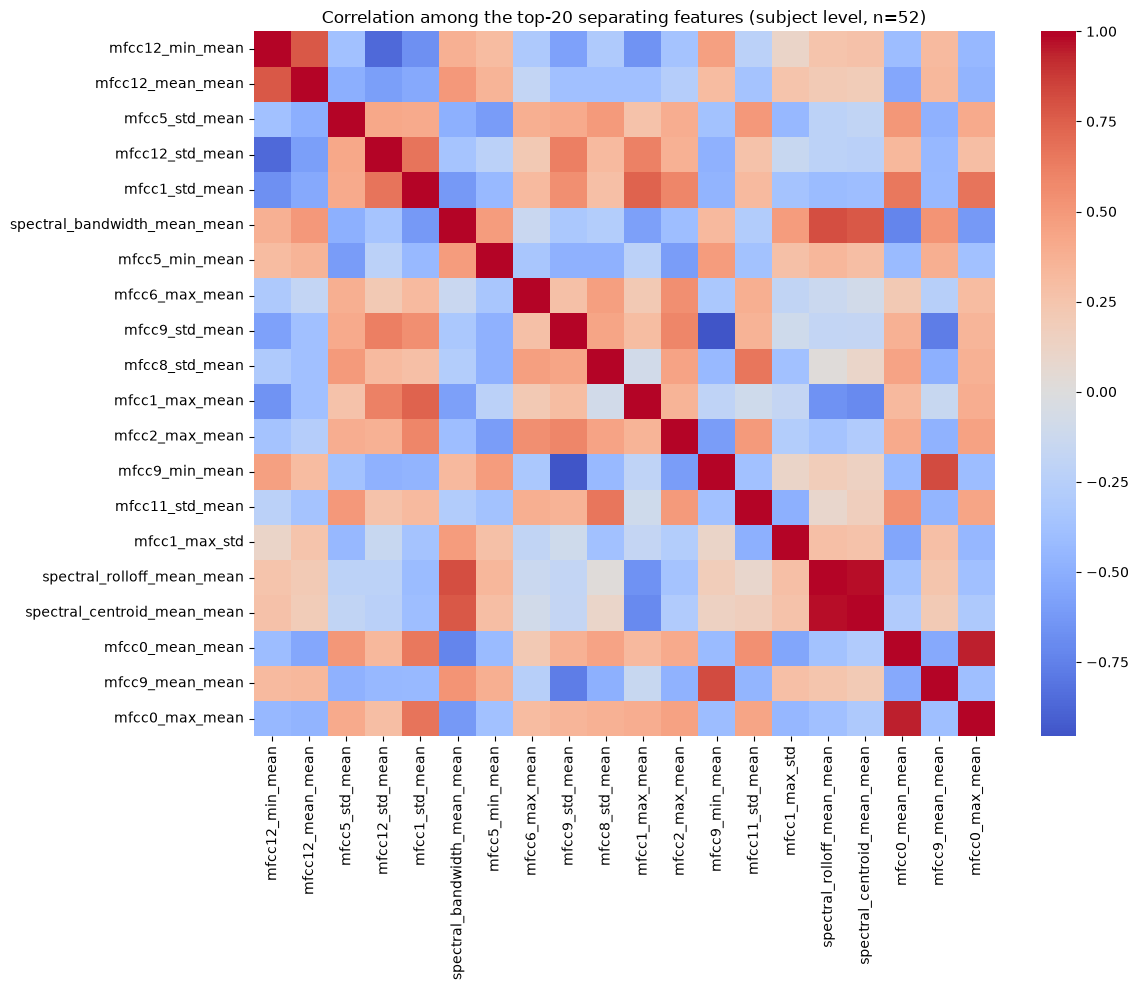

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

top_features = separation_df.head(20)["feature"].tolist()
corr = subject_features_df[top_features].corr()

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr, cmap="coolwarm", center=0, ax=ax, xticklabels=True, yticklabels=True)
ax.set_title("Correlation among the top-20 separating features (subject level, n=52)")
plt.tight_layout()
plt.show()

## Benchmark context

The companion methods paper ("A Novel Decision Tree for Depression Recognition in Speech", same 52-subject cohort) reports **75.8% (male) / 68.5% (female)** accuracy using a decision-tree speech-segment-fusion method (see `DATA_CONTEXT.md` section 7). Not reproduced here — this notebook is EDA, not a modeling pipeline — but it's the external reference point any future baseline model built from these features should be compared against.

## Summary and next steps

- Feature extraction: 1491 files (1503 valid − 12 duration outliers), 70 features/file, zero NaN/inf. Cached to `backend/data/processed/features.csv` (~168s to extract from scratch, ~3s to reload from cache — both paths verified).
- All separability analysis above is at the **subject level** (n=52, 140 mean/std-aggregated features), not file level — a subject's ~29 recordings are correlated, so file-level separation would be inflated and misleading.
- Top acoustic separators (by |Cohen's d|): **mfcc12_min_mean** (d=1.22), **mfcc12_mean_mean** (d=1.18), mfcc5_std_mean (d=-1.13), mfcc12_std_mean (d=-0.96), mfcc1_std_mean (d=-0.95), spectral_bandwidth_mean_mean (d=0.90) — MFCC-family features dominate the top of the ranking.
- These acoustic effect sizes are meaningfully **weaker** than the non-leaky metadata scales from `02_clinical_metadata_eda.ipynb` (GAD-7 d=3.74, PSQI d=2.37) — acoustic features carry real but noisier signal than self-report clinical scales, which is the expected pattern for this kind of task, not a defect.
- Next steps (out of scope for this EDA notebook): any future baseline model must use subject-level grouped cross-validation (e.g. `GroupKFold`/leave-subjects-out) given n=52 — a plain `train_test_split` (as currently implemented in `trainer.py`) would leak subjects across train/test. External benchmark to beat: 75.8% (male) / 68.5% (female) accuracy from the companion paper.